In [5]:
import sys 
sys.path.append('../..')

import jax
from functools import partial
from jax import grad, jacfwd, vmap, jit, hessian, value_and_grad
from jax.lax import scan
# from jax.ops import index_update, index
import jax.random as jnp_random
import jax.numpy as np

from jax.flatten_util import ravel_pytree

import numpy as onp
from time_opt_erg_lib.ergodic_metric import ErgodicMetric
from time_opt_erg_lib.fourier_utils import BasisFunc, get_phik, get_ck, recon_from_fourier
from IPython.display import clear_output
import matplotlib.pyplot as plt

from time_opt_erg_lib.opt_solver import AugmentedLagrangeSolver
from time_opt_erg_lib.target_distribution import TargetDistribution
import yaml
import pickle as pkl


In [42]:
class UniformDistr(object):
    def __init__(self) -> None:
        self.n = 2
        self.domain = np.meshgrid(
            *[np.linspace(0,1)]*self.n
        )
        self._s = np.stack([X.ravel() for X in self.domain]).T
        self.evals = (
            vmap(self.p)(self._s) , self._s
        )
    
    def plot(self):
        plt.contour(self.domain[0], self.domain[1], self.evals[0].reshape(self.domain[0].shape))

    def p(self, x):
        return 1.0

    def update(self):
        pass

class MultGaussianDistr(object):
    def __init__(self) -> None:
        self.n = 2
        self.domain = np.meshgrid(
            *[np.linspace(0,1)]*self.n
        )
        self._s = np.stack([X.ravel() for X in self.domain]).T
        _evals = vmap(self.p)(self._s)
        self.evals = (
            _evals/_evals.sum() , self._s
        )
    
    def plot(self):
        plt.contour(self.domain[0], self.domain[1], self.evals[0].reshape(self.domain[0].shape))

    def p(self, x):
        return np.exp(-60.5 * np.sum((x[:2] - 0.3)**2)) \
                    + np.exp(-60.5 * np.sum((x[:2] - 0.55)**2)) \
                    + np.exp(-60.5 * np.sum((x[:2] - np.array([0.6, 0.45]))**2)) \
        #             + np.exp(-60.5 * np.sum((x[:2] - np.array([0.75, 0.2]))**2))
    def update(self):
        pass

class GaussianDistr(object):
    def __init__(self) -> None:
        self.n = 2
        self.domain = np.meshgrid(
            *[np.linspace(0,1)]*self.n
        )
        self._s = np.stack([X.ravel() for X in self.domain]).T
        _evals = vmap(self.p)(self._s)
        self.evals = (
            _evals/_evals.sum() , self._s
        )
    
    def plot(self):
        plt.contour(self.domain[0], self.domain[1], self.evals[0].reshape(self.domain[0].shape))

    def p(self, x):
        return np.exp(-150.5 * np.sum((x[:2] - 1)**2))
        # return 1
        # return np.exp(-60.5 * np.sum((x[:2] - 0.2)**2)) \
        #             + np.exp(-60.5 * np.sum((x[:2] - 0.75)**2)) \
        #             + np.exp(-60.5 * np.sum((x[:2] - np.array([0.2, 0.75]))**2)) \
        #             + np.exp(-60.5 * np.sum((x[:2] - np.array([0.75, 0.2]))**2))
    def update(self):
        pass

class RevGaussianDistr(object):
    def __init__(self) -> None:
        self.n = 2
        self.domain = np.meshgrid(
            *[np.linspace(0,1)]*self.n
        )
        self._s = np.stack([X.ravel() for X in self.domain]).T
        _evals = vmap(self.p)(self._s)
        self.evals = (
            _evals/_evals.sum() , self._s
        )
    
    def plot(self):
        plt.contour(self.domain[0], self.domain[1], self.evals[0].reshape(self.domain[0].shape))

    def p(self, x):
        return 1 - np.exp(-150.5 * np.sum((x[:2] - 1)**2)) 
        # return 1
        # return np.exp(-60.5 * np.sum((x[:2] - 0.2)**2)) \
        #             + np.exp(-60.5 * np.sum((x[:2] - 0.75)**2)) \
        #             + np.exp(-60.5 * np.sum((x[:2] - np.array([0.2, 0.75]))**2)) \
        #             + np.exp(-60.5 * np.sum((x[:2] - np.array([0.75, 0.2]))**2))
    def update(self):
        pass

In [52]:
def get_phik(vals, basis):
    _phi, _x = vals 
    phik = np.dot(_phi, vmap(basis.fk_vmap)(_x))
    phik = phik/phik[0]
    phik = phik/basis.hk_list
    return phik
def get_ck(trajectory, basis, tf, dt):
    ck = np.sum(vmap(basis.fk_vmap)(trajectory), axis=0)
    ck = ck / ck[0]
    ck = ck / basis.hk_list
    return ck

In [53]:
basis       = BasisFunc([20]*2)
metric      = ErgodicMetric(basis)
unif        = UniformDistr()
gauss       = GaussianDistr()
mult_gauss       = MultGaussianDistr()
rev_gauss       = RevGaussianDistr()

# zero_distr  = (unif.evals[0]*0, unif.evals[1])
# zero_phik   = get_phik(zero_distr, basis)
multgauss_phik = get_phik(mult_gauss.evals, basis)
unif_phik   = get_phik(unif.evals, basis)
gauss_phik  = get_phik(gauss.evals, basis)
rev_gauss_phik  = get_phik(rev_gauss.evals, basis)



In [61]:
def loss(params):
    x = params['x']
    ck = get_ck(x, basis, 1, 1) 
    return metric(multgauss_phik, ck)

def upper_bound(params):
    x1 = params['x1']
    x2 = params['x2']
    ck1 = get_ck(x1.reshape((1,-1)), basis, 1, 1) 
    ck2 = get_ck(x2.reshape((1,-1)), basis, 1, 1) 
    return metric(unif_phik, 2*ck1), metric(unif_phik, 2*ck2) 


params = {
    'x' : np.array(onp.random.uniform(0,1,size=(20,2))),
}
log = []
for _ in range(1000):
    d_params = grad(loss)(params)
    params['x'] = params['x'] + 0.01*d_params['x']
    log.append(loss(params))
    print('loss', log[-1], 'norm phik', metric(multgauss_phik, multgauss_phik*0))

loss 0.23756206 norm phik 1.2114267
loss 0.23947243 norm phik 1.2114267
loss 0.24139716 norm phik 1.2114267
loss 0.24333623 norm phik 1.2114267
loss 0.24528949 norm phik 1.2114267
loss 0.2472571 norm phik 1.2114267
loss 0.24923898 norm phik 1.2114267
loss 0.25123513 norm phik 1.2114267
loss 0.25324535 norm phik 1.2114267
loss 0.25526983 norm phik 1.2114267
loss 0.2573083 norm phik 1.2114267
loss 0.25936067 norm phik 1.2114267
loss 0.2614269 norm phik 1.2114267
loss 0.26350677 norm phik 1.2114267
loss 0.26560026 norm phik 1.2114267
loss 0.26770705 norm phik 1.2114267
loss 0.2698273 norm phik 1.2114267
loss 0.27196065 norm phik 1.2114267
loss 0.27410686 norm phik 1.2114267
loss 0.27626586 norm phik 1.2114267
loss 0.2784375 norm phik 1.2114267
loss 0.2806217 norm phik 1.2114267
loss 0.28281826 norm phik 1.2114267
loss 0.28502715 norm phik 1.2114267
loss 0.2872482 norm phik 1.2114267
loss 0.28948143 norm phik 1.2114267
loss 0.29172677 norm phik 1.2114267
loss 0.29398397 norm phik 1.2114267

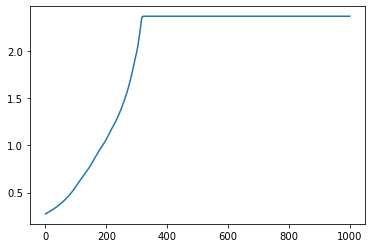

In [59]:
plt.plot(log)

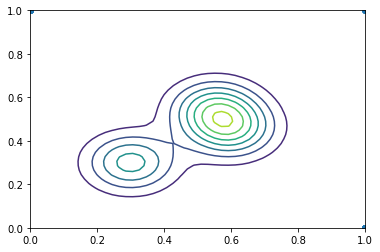

In [60]:
mult_gauss.plot()
plt.scatter(params['x'][:,0], params['x'][:,1])